# Almaty apartment price model v2

## tl;dr

Executed held-out result: **log RMSE 0.1328**, approximately
**14.2% multiplicative error**, median
absolute percentage error **7.1%**,
and q10–q90 coverage **72.8%** on
**4,377 test rows**.

**Status: provisional.** Almaty scrape has incomplete room partitions; metrics are provisional. The notebook saves a candidate bundle only and
does not replace the production Astana model.

## Context & Methods

The target is the natural logarithm of listing price per square metre.
The feature set is shared across cities and uses city-qualified districts
and residential complexes, H3 cells, building/apartment attributes, and
distances and local counts for eight OpenStreetMap POI categories.

To reduce leakage from duplicated or reposted apartments, split assignment
is based on a stable hash of a property-like group (city, H3 cell, ЖК,
rooms, area, floors, and construction year). All rows in the same group
remain in the same train/validation/test partition. The Almaty notebook
uses the exact same split rule, which makes its test rows directly
comparable with the Almaty slice of the universal notebook.

### Key Assumptions

- Krisha asking prices are treated as market signals, not completed sale prices.
- Rows outside 100,000–5,000,000 KZT/m² are removed as likely input errors or
  out-of-domain luxury/special cases.
- OSM distances are straight-line distances to representative POI points,
  not walking or driving routes.
- `listing_url`, scrape timestamps, and scrape partitions are audit fields;
  they never enter CatBoost.
- Candidate models are not production-ready while the Almaty room partitions
  are incomplete.

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "app" / "feature_pipeline_v2.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")

ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "universal_training_v2.csv"
METADATA_PATH = ROOT / "models_candidate" / "universal_v2_model_metadata.json"
SCRAPE_STATE_PATH = ROOT / "data" / "almaty_sale_raw.state.json"
OUTPUT_DIR = ROOT / "models_candidate" / "almaty_v2" / "notebook_baseline"

SCOPE = "almaty"
RANDOM_SEED = 42
PRICE_PER_M2_MIN = 100_000
PRICE_PER_M2_MAX = 5_000_000
ITERATIONS = 500
DEPTH = 7
LEARNING_RATE = 0.05
EARLY_STOPPING_ROUNDS = 75
SAVE_CANDIDATE_MODELS = True
REBUILD_DATASET = False

print(f"Repository: {ROOT}")
print(f"Scope: {SCOPE}")

Repository: C:\Users\kaira\OneDrive\Documents\KrishaListings\Pet-projects
Scope: almaty


## Data

In [2]:
if REBUILD_DATASET:
    command = [
        sys.executable,
        str(ROOT / "scripts" / "build_universal_dataset.py"),
        "--input", str(ROOT / "krisha_data_raw_orig.csv"),
        "--input", str(ROOT / "krisha_data_raw.csv"),
        "--input", str(ROOT / "data" / "almaty_sale_raw.csv"),
    ]
    astana_refresh = ROOT / "data" / "astana_sale_raw.csv"
    if astana_refresh.exists():
        command.extend(["--input", str(astana_refresh)])
    subprocess.run(command, cwd=ROOT, check=True)

if not DATA_PATH.exists() or not METADATA_PATH.exists():
    raise FileNotFoundError(
        "Build data/universal_training_v2.csv first; see DATA.md."
    )

df_all = pd.read_csv(DATA_PATH, low_memory=False)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
feature_columns = metadata["feature_columns"]
categorical_features = metadata["categorical_features"]
target_column = metadata["target"]

missing_features = sorted(set(feature_columns) - set(df_all.columns))
if missing_features:
    raise ValueError(f"Dataset is missing model features: {missing_features}")

price_per_m2 = np.exp(pd.to_numeric(df_all[target_column], errors="coerce"))
domain_mask = price_per_m2.between(PRICE_PER_M2_MIN, PRICE_PER_M2_MAX)
removed_outliers = int((~domain_mask).sum())
df = df_all.loc[domain_mask].copy()
if SCOPE == "almaty":
    df = df.loc[df["city"].eq("almaty")].copy()

state = {}
if SCRAPE_STATE_PATH.exists():
    state = json.loads(SCRAPE_STATE_PATH.read_text(encoding="utf-8"))
partitions = state.get("partitions", {})
almaty_inventory_complete = bool(partitions) and all(
    item.get("complete", False) for item in partitions.values()
)

display(Markdown(
    "✅ Almaty collector reports all room partitions complete."
    if almaty_inventory_complete
    else "⚠️ **Provisional dataset:** Almaty room partitions are incomplete. "
         "Do not promote these models to production yet."
))
print(f"Rows loaded: {len(df_all):,}")
print(f"Out-of-domain rows removed globally: {removed_outliers:,}")
print(f"Rows in notebook scope: {len(df):,}")
display(df.groupby(["city", "rooms"], dropna=False).size().rename("rows").to_frame())

⚠️ **Provisional dataset:** Almaty room partitions are incomplete. Do not promote these models to production yet.

Rows loaded: 44,935
Out-of-domain rows removed globally: 3
Rows in notebook scope: 28,706


rows
city   rooms        
almaty 1.000   10828
       2.000    9103
       3.000    7598
       4.000     922
       5.000     167
       6.000      43
       7.000      27
       8.000       6
       9.000       3
       10.000      5
       11.000      3
       12.000      1

In [3]:
audit_columns = [column for column in [
    "listing_url", "scraped_at", "scrape_partition"
] if column in df.columns]
quality = pd.DataFrame({
    "missing_pct": df[feature_columns].isna().mean().mul(100),
    "unique_values": df[feature_columns].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print(f"Unique listing URLs: {df['listing_url'].nunique():,}" if "listing_url" in df else "No URL audit column")
print(f"Audit fields excluded from the model: {audit_columns}")
display(quality.head(15))

Unique listing URLs: 28,706
Audit fields excluded from the model: ['listing_url', 'scraped_at', 'scrape_partition']


,missing_pct,unique_values
ceiling_height,20.334,87
current_floor,3.592,29
total_floors,3.592,32
floor_ratio,3.592,182
city,0.000,1
count_mall_within_2km,0.000,23
count_kindergarten_within_500m,0.000,9
count_kindergarten_within_1km,0.000,14
count_kindergarten_within_2km,0.000,31
dist_to_nearest_grocery_km,0.000,16661


In [4]:
def normalized_token(series: pd.Series) -> pd.Series:
    return series.fillna("__missing__").astype(str).str.strip().str.lower()

def rounded_token(series: pd.Series, decimals: int = 1) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").round(decimals)
    return values.fillna(-999999).astype(str)

group_parts = [
    normalized_token(df["city"]),
    normalized_token(df["h3_res_9"]),
    normalized_token(df["city_residential_complex"]),
    rounded_token(df["rooms"], 0),
    rounded_token(df["area_m2"], 1),
    rounded_token(df["current_floor"], 0),
    rounded_token(df["total_floors"], 0),
    rounded_token(df["year_of_construction"], 0),
]
property_group = group_parts[0]
for part in group_parts[1:]:
    property_group = property_group.str.cat(part, sep="|")

buckets = property_group.map(
    lambda value: int(hashlib.sha256(value.encode("utf-8")).hexdigest()[:8], 16) % 100
)
df["split"] = np.select(
    [buckets.lt(70), buckets.lt(85)], ["train", "validation"], default="test"
)
df["property_group"] = property_group

leakage_check = df.groupby("property_group")["split"].nunique().max()
assert leakage_check == 1, "A property-like group crossed split boundaries."
split_summary = df.groupby(["split", "city"]).size().unstack(fill_value=0)
display(split_summary)

city,almaty
split,
test,4377
train,20032
validation,4297


## Results

In [5]:
for column in categorical_features:
    df[column] = df[column].fillna("__missing__").astype(str)
numeric_features = [column for column in feature_columns if column not in categorical_features]
for column in numeric_features:
    df[column] = pd.to_numeric(df[column], errors="coerce")

subsets = {name: df.loc[df["split"].eq(name)].copy() for name in ["train", "validation", "test"]}
if min(len(part) for part in subsets.values()) == 0:
    raise ValueError("At least one split is empty.")

X = {name: part[feature_columns] for name, part in subsets.items()}
y = {name: pd.to_numeric(part[target_column], errors="raise") for name, part in subsets.items()}
cat_indices = [feature_columns.index(column) for column in categorical_features]

quantile_alphas = {"q10": 0.10, "q50": 0.50, "q90": 0.90}
models = {}
predictions = {}

for label, alpha in quantile_alphas.items():
    print(f"Training {label}...")
    model = CatBoostRegressor(
        loss_function=f"Quantile:alpha={alpha}",
        eval_metric=f"Quantile:alpha={alpha}",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=RANDOM_SEED,
        l2_leaf_reg=5,
        random_strength=0.5,
        verbose=100,
        allow_writing_files=False,
        thread_count=-1,
    )
    model.fit(
        X["train"], y["train"],
        cat_features=cat_indices,
        eval_set=(X["validation"], y["validation"]),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        use_best_model=True,
    )
    models[label] = model
    predictions[label] = model.predict(X["test"])

Training q10...


0:	learn: 0.0447414	test: 0.0432430	best: 0.0432430 (0)	total: 206ms	remaining: 1m 42s


100:	learn: 0.0229830	test: 0.0241086	best: 0.0241086 (100)	total: 8.26s	remaining: 32.6s


200:	learn: 0.0205193	test: 0.0227148	best: 0.0227148 (200)	total: 16.4s	remaining: 24.4s


300:	learn: 0.0191461	test: 0.0220639	best: 0.0220639 (300)	total: 24.4s	remaining: 16.1s


...

100:	learn: 0.0237212	test: 0.0242116	best: 0.0242116 (100)	total: 8.03s	remaining: 31.7s


200:	learn: 0.0214279	test: 0.0233132	best: 0.0233132 (200)	total: 16.2s	remaining: 24s


300:	learn: 0.0201348	test: 0.0229720	best: 0.0229698 (298)	total: 24.3s	remaining: 16.1s


400:	learn: 0.0194398	test: 0.0228466	best: 0.0228466 (400)	total: 32.5s	remaining: 8.02s


499:	learn: 0.0188548	test: 0.0227718	best: 0.0227698 (497)	total: 40.5s	remaining: 0us

bestTest = 0.02276977309
bestIteration = 497

Shrink model to first 498 iterations.


In [6]:
def regression_metrics(actual_log, pred_log, pred_low=None, pred_high=None):
    actual_log = np.asarray(actual_log)
    pred_log = np.asarray(pred_log)
    actual = np.exp(actual_log)
    predicted = np.exp(pred_log)
    log_rmse = float(np.sqrt(mean_squared_error(actual_log, pred_log)))
    result = {
        "rows": int(len(actual_log)),
        "log_rmse": log_rmse,
        "approx_multiplicative_error_pct": float(np.expm1(log_rmse) * 100),
        "log_mae": float(mean_absolute_error(actual_log, pred_log)),
        "log_r2": float(r2_score(actual_log, pred_log)),
        "mae_kzt_per_m2": float(mean_absolute_error(actual, predicted)),
        "rmse_kzt_per_m2": float(np.sqrt(mean_squared_error(actual, predicted))),
        "median_absolute_percentage_error_pct": float(
            np.median(np.abs(predicted - actual) / actual) * 100
        ),
    }
    if pred_low is not None and pred_high is not None:
        result["q10_q90_coverage_pct"] = float(
            np.mean((actual_log >= pred_low) & (actual_log <= pred_high)) * 100
        )
        result["bad_quantile_order_pct"] = float(
            np.mean((pred_low > pred_log) | (pred_log > pred_high)) * 100
        )
    return result

overall_metrics = regression_metrics(
    y["test"], predictions["q50"], predictions["q10"], predictions["q90"]
)
display(pd.DataFrame([overall_metrics], index=["test_overall"]).T)

test_results = subsets["test"][["city", "rooms", "listing_url"]].reset_index(drop=True)
test_results["actual_log"] = y["test"].to_numpy()
for label, values in predictions.items():
    test_results[f"pred_{label}_log"] = values

def room_segment(value):
    if pd.isna(value):
        return "missing"
    numeric = float(value)
    return "5+" if numeric >= 5 else str(int(numeric))

test_results["rooms_segment"] = test_results["rooms"].map(room_segment)

segment_rows = []
segment_column = "city" if SCOPE == "universal" else "rooms_segment"
for segment, part in test_results.groupby(segment_column):
    if len(part) < 30:
        continue
    values = regression_metrics(
        part["actual_log"], part["pred_q50_log"],
        part["pred_q10_log"], part["pred_q90_log"],
    )
    values["segment"] = segment
    segment_rows.append(values)
segment_metrics = pd.DataFrame(segment_rows).set_index("segment") if segment_rows else pd.DataFrame()
display(segment_metrics)

,test_overall
rows,"4,377.000"
log_rmse,0.133
approx_multiplicative_error_pct,14.197
log_mae,0.095
log_r2,0.790
mae_kzt_per_m2,"78,393.903"
rmse_kzt_per_m2,"129,239.962"
median_absolute_percentage_error_pct,7.107
q10_q90_coverage_pct,72.790
bad_quantile_order_pct,0.160


,rows,log_rmse,approx_multiplicative_error_pct,log_mae,log_r2,mae_kzt_per_m2,rmse_kzt_per_m2,median_absolute_percentage_error_pct,q10_q90_coverage_pct,bad_quantile_order_pct
segment,,,,,,,,,,
1,1670,0.119,12.602,0.083,0.749,"62,988.115","96,727.760",6.233,73.533,0.240
2,1422,0.125,13.328,0.093,0.809,"74,253.901","109,279.155",7.372,72.082,0.141
3,1122,0.139,14.880,0.103,0.819,"89,215.279","151,509.141",8.039,73.797,0.089
4,115,0.197,21.797,0.147,0.679,"159,488.756","234,209.422",9.982,73.913,0.000
5+,48,0.332,39.368,0.261,0.441,"289,795.061","419,294.002",22.317,41.667,0.000


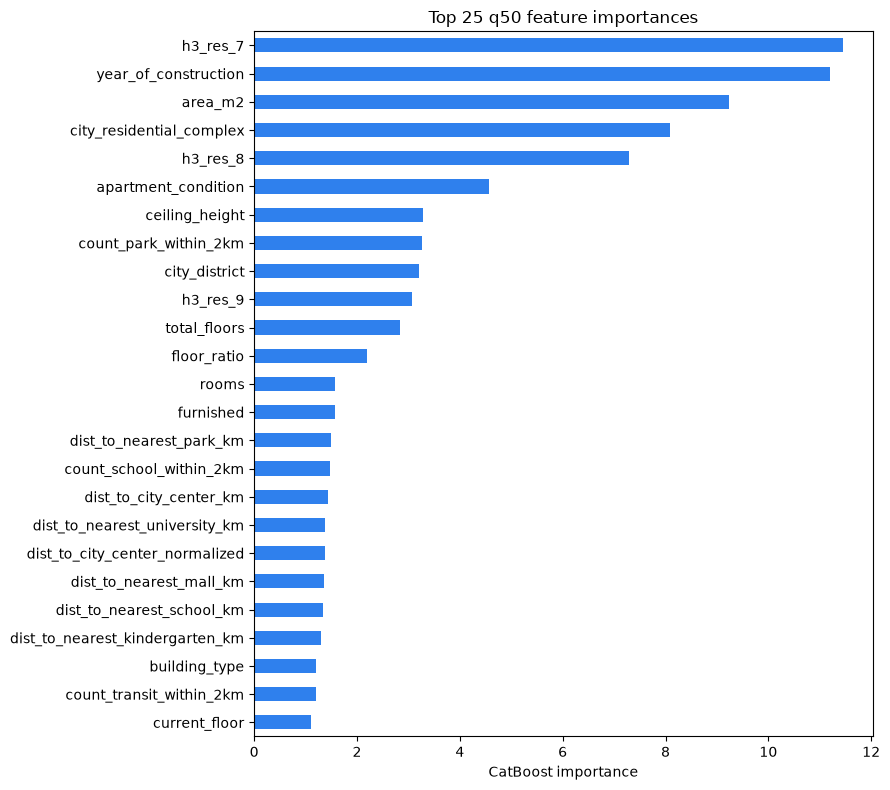

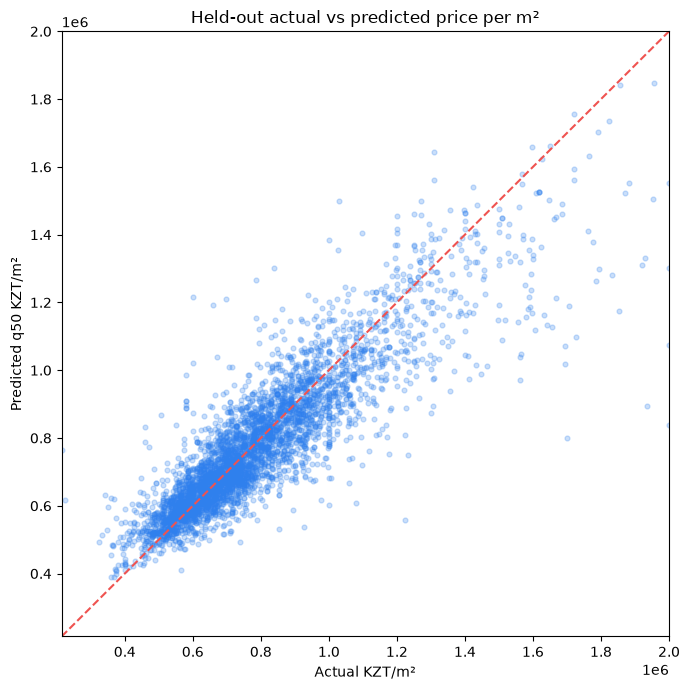

In [7]:
importance = pd.Series(
    models["q50"].get_feature_importance(), index=feature_columns
).sort_values(ascending=False).head(25).sort_values()
ax = importance.plot.barh(figsize=(9, 8), color="#2f80ed")
ax.set_title("Top 25 q50 feature importances")
ax.set_xlabel("CatBoost importance")
plt.tight_layout()
plt.show()

actual = np.exp(test_results["actual_log"])
predicted = np.exp(test_results["pred_q50_log"])
lower = float(min(actual.min(), predicted.min()))
upper = float(max(actual.quantile(0.995), predicted.quantile(0.995)))
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual, predicted, s=12, alpha=0.25, color="#2f80ed")
ax.plot([lower, upper], [lower, upper], linestyle="--", color="#ef5350")
ax.set(xlim=(lower, upper), ylim=(lower, upper),
       xlabel="Actual KZT/m²", ylabel="Predicted q50 KZT/m²",
       title="Held-out actual vs predicted price per m²")
plt.tight_layout()
plt.show()

In [8]:
evaluation = {
    "scope": SCOPE,
    "production_ready": False,
    "data_inventory_complete": bool(almaty_inventory_complete),
    "warning": None if almaty_inventory_complete else (
        "Almaty scrape has incomplete room partitions; metrics are provisional."
    ),
    "dataset_path": str(DATA_PATH.relative_to(ROOT)),
    "rows_after_scope_and_filter": int(len(df)),
    "rows_by_split": {key: int(value) for key, value in df["split"].value_counts().items()},
    "price_per_m2_filter": [PRICE_PER_M2_MIN, PRICE_PER_M2_MAX],
    "split_definition": (
        "sha256(city|h3_res_9|city_residential_complex|rooms|area_m2|"
        "current_floor|total_floors|year_of_construction) modulo 100; "
        "0-69 train, 70-84 validation, 85-99 test"
    ),
    "parameters": {
        "iterations": ITERATIONS,
        "depth": DEPTH,
        "learning_rate": LEARNING_RATE,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "random_seed": RANDOM_SEED,
    },
    "best_iterations": {name: int(model.get_best_iteration()) for name, model in models.items()},
    "overall_test_metrics": overall_metrics,
    "segment_test_metrics": segment_metrics.reset_index().to_dict(orient="records"),
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
}

if SAVE_CANDIDATE_MODELS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for label, model in models.items():
        model.save_model(OUTPUT_DIR / f"model_{label}.cbm")
    (OUTPUT_DIR / "evaluation.json").write_text(
        json.dumps(evaluation, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    print(f"Candidate bundle saved to: {OUTPUT_DIR}")

Candidate bundle saved to: C:\Users\kaira\OneDrive\Documents\KrishaListings\Pet-projects\models_candidate\almaty_v2\notebook_baseline


## Takeaways

Use the held-out `log_rmse`, median percentage error, interval coverage,
and city/room slices together; no single metric is sufficient. A low
random-split score would not prove geographic or future-time
generalisation.

Before production promotion, finish all Almaty room partitions, rebuild
the shared dataset, rerun both notebooks, compare the Almaty rows on the
identical group-hash test split, and then run a later-scrape temporal
holdout. The notebook output is a candidate bundle only.